# Solve Navier-Stokes equation based on Fourier Neural Operator

[![DownloadNotebook](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_notebook_en.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/master/mindflow/en/data_driven/mindspore_navier_stokes_FNO2D.ipynb)&emsp;[![DownloadCode](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_download_code_en.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/master/mindflow/en/data_driven/mindspore_navier_stokes_FNO2D.py)&emsp;[![ViewSource](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_source_en.png)](https://gitee.com/mindspore/docs/blob/master/docs/mindflow/docs/source_en/data_driven/navier_stokes_FNO2D.ipynb)

## Overview

Computational fluid dynamics is one of the most important techniques in the field of fluid mechanics in the 21st century. The flow analysis, prediction and control can be realized by solving the governing equations of fluid mechanics by numerical method. Traditional finite element method (FEM) and finite difference method (FDM) are inefficient because of the complex simulation process (physical modeling, meshing, numerical discretization, iterative solution, etc.) and high computing costs. Therefore, it is necessary to improve the efficiency of fluid simulation with AI.

Machine learning methods provide a new paradigm for scientific computing by providing a fast solver similar to traditional methods. Classical neural networks learn mappings between finite dimensional spaces and can only learn solutions related to specific discretizations. Different from traditional neural networks, Fourier Neural Operator (FNO) is a new deep learning architecture that can learn mappings between infinite-dimensional function spaces. It directly learns mappings from arbitrary function parameters to solutions to solve a class of partial differential equations.  Therefore, it has a stronger generalization capability. More information can be found in the paper, [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/abs/2010.08895).

This tutorial describes how to solve the Navier-Stokes equation using Fourier neural operator.

## Navier-Stokes equation

Navier-Stokes equation is a classical equation in computational fluid dynamics. It is a set of partial differential equations describing the conservation of fluid momentum, called N-S equation for short. Its vorticity form in two-dimensional incompressible flows is as follows:

$$
\partial_t w(x, t)+u(x, t) \cdot \nabla w(x, t)=\nu \Delta w(x, t)+f(x), \quad x \in(0,1)^2, t \in(0, T]
$$

$$
\nabla \cdot u(x, t)=0, \quad x \in(0,1)^2, t \in[0, T]
$$

$$
w(x, 0)=w_0(x), \quad x \in(0,1)^2
$$

where $u$ is the velocity field, $w=\nabla \times u$ is the vorticity, $w_0(x)$ is the initial vorticity, $\nu$ is the viscosity coefficient, $f(x)$ is the forcing function.


## Problem Description

We aim to solve two-dimensional incompressible N-S equation by learning the operator mapping from each time step to the next time step:

$$
w_t \mapsto w(\cdot, t+1)
$$

## Technology Path

MindFlow solves the problem as follows:

1. Training Dataset Construction.
2. Model Construction.
3. Optimizer and Loss Function.
4. Model Training.

## Fourier Neural Operator

The following figure shows the architecture of the Fourier Neural Operator model. In the figure, $w_0(x)$ represents the initial vorticity.  The input vector is lifted to higher dimension channel space by the lifting layer. Then the mapping result is used as the input of the Fourier layer to perform nonlinear transformation of the frequency domain information. Finally, the decoding layer maps the transformation result to the final prediction result $w_1(x)$.

The Fourier Neural Operator consists of the lifting Layer, Fourier Layers, and the decoding Layer.

![Fourier Neural Operator model structure](images/FNO.png)

Fourier layers: Start from input V. On top: apply the Fourier transform $\mathcal{F}$; a linear transform R on the lower Fourier modes and filters out the higher modes; then apply the inverse Fourier transform $\mathcal{F}^{-1}$. On the bottom: apply a local linear transform W.  Finally, the Fourier Layer output vector is obtained through the activation function.

![Fourier Layer structure](images/FNO-2.png)

In [1]:
import sys
import os
project_root = os.path.abspath("../../../../..")
sys.path.append(project_root)

In [2]:
import os
import time
import numpy as np

import mindspore
import mindspore.common.dtype as mstype
from mindspore import nn, context, ops, Tensor, jit, set_seed, save_checkpoint
from IPython.display import Image, display

/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


The following `src` pacakage can be downloaded in [applications/data_driven/navier_stokes/fno2d/src](https://gitee.com/mindspore/mindscience/tree/master/MindFlow/applications/data_driven/navier_stokes/fno2d/src).

In [3]:
from mindscience.models import FNO2D
from mindscience.common import get_warmup_cosine_annealing_lr
from mindscience.common import RelativeRMSELoss
from mindscience.utils import load_yaml_config
from mindscience.pde import UnsteadyFlowWithLoss
from src import calculate_l2_error, create_training_dataset, visual

set_seed(0)
np.random.seed(0)

In [4]:
# set context for training: using graph mode for high performance training with GPU acceleration
context.set_context(mode=context.GRAPH_MODE, device_target='Ascend', device_id=1,max_device_memory="32GB")
use_ascend = context.get_context(attr_key='device_target') == "Ascend"
config = load_yaml_config('./configs/fno2d.yaml')
data_params = config["data"]
model_params = config["model"]
optimizer_params = config["optimizer"]
summary_params = config["summary"]

## Training Dataset Construction

Download the training and test dataset: [data_driven/navier_stokes/dataset](https://download.mindspore.cn/mindscience/mindflow/dataset/applications/data_driven/navier_stokes/dataset/) .

In this case, training data sets and test data sets are generated according to Zongyi Li's data set in [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/pdf/2010.08895.pdf) . The settings are as follows:

The initial condition $w_0(x)$ is generated according to periodic boundary conditions:

$$
w_0 \sim \mu, \mu=\mathcal{N}\left(0,7^{3 / 2}(-\Delta+49 I)^{-2.5}\right)
$$

The forcing function is defined as:

$$
f(x)=0.1\left(\sin \left(2 \pi\left(x_1+x_2\right)\right)+\right.\cos(2 \pi(x_1+x_2)))
$$

We use a time-step of 1e-4 for the Crank–Nicolson scheme in the data-generated process where we record the solution every t = 1 time units.  All data are generated on a 256 × 256 grid and are downsampled to 64 × 64.  In this case, the viscosity coefficient $\nu=1e-5$, the number of samples in the training set is 19000, and the number of samples in the test set is 3800.

In [5]:
train_dataset = create_training_dataset(data_params, input_resolution=model_params["input_resolution"], shuffle=True)
test_input = np.load(os.path.join(data_params["root_dir"], "test/inputs.npy"))
test_label = np.load(os.path.join(data_params["root_dir"], "test/label.npy"))

data_path = data_params['root_dir']

resolution = data_params['resolution']
batch_size = data_params['batch_size']
n_batches = data_params['test_size'] // batch_size
data_shape = (n_batches, batch_size, resolution, resolution)
labels_unif = np.load(os.path.join(data_path, "test/label.npy")).reshape(data_shape)

Data preparation finished


## Model Construction

The network is composed of 1 lifting layer, multiple Fourier layers and 1 decoding layer:

- The Lifting layer corresponds to the `FNO2D.fc0` in the case, and maps the output data $x$ to the high dimension;

- Multi-layer Fourier Layer corresponds to the `FNO2D.fno_seq` in the case. Discrete Fourier transform is used to realize the conversion between time domain and frequency domain;

- The Decoding layer corresponds to `FNO2D.fc1` and `FNO2D.fc2` in the case to obtain the final predictive value.

In [6]:
if use_ascend:
    compute_type = mstype.float16
else:
    compute_type = mstype.float32
# prepare model
model = FNO2D(in_channels=model_params["in_channels"],
              out_channels=model_params["out_channels"],
              n_modes=[model_params["modes"], model_params["modes"]],
              resolutions=[model_params["input_resolution"], model_params["input_resolution"]],
              hidden_channels=model_params["width"],
              n_layers=model_params["depth"],
              projection_channels=4*model_params["width"],
              fno_compute_dtype=compute_type)

model_params_list = []
for k, v in model_params.items():
    model_params_list.append(f"{k}-{v}")
model_name = "_".join(model_params_list)

## Optimizer and Loss Function

Use the relative root mean square error as the loss function for network training:

In [7]:
steps_per_epoch = train_dataset.get_dataset_size()
lr = get_warmup_cosine_annealing_lr(lr_init=optimizer_params["learning_rate"],
                                    last_epoch=optimizer_params["epochs"],
                                    steps_per_epoch=steps_per_epoch,
                                    warmup_epochs=optimizer_params["warmup_epochs"])

optimizer = nn.AdamWeightDecay(model.trainable_params(), learning_rate=Tensor(lr),
                               weight_decay=optimizer_params['weight_decay'])

problem = UnsteadyFlowWithLoss(model, loss_fn=RelativeRMSELoss(), data_format="NHWTC")

if use_ascend:
    from mindspore.amp import DynamicLossScaler, auto_mixed_precision, all_finite
    loss_scaler = DynamicLossScaler(1024, 2, 100)
    auto_mixed_precision(model, "O3")
else:
    loss_scaler = None

## Model Training

With **MindSpore version >= 2.0.0**, we can use the functional programming for training neural networks.

In [8]:
def train():
    def forward_fn(train_inputs, train_label):
        loss = problem.get_loss(train_inputs, train_label)
        if use_ascend:
            loss = loss_scaler.scale(loss)
        return loss

    grad_fn = ops.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=False)

    @jit
    def train_step(train_inputs, train_label):
        loss, grads = grad_fn(train_inputs, train_label)
        if use_ascend:
            loss = loss_scaler.unscale(loss)
            is_finite = all_finite(grads)
            if is_finite:
                grads = loss_scaler.unscale(grads)
                loss = ops.depend(loss, optimizer(grads))
            loss_scaler.adjust(is_finite)
        else:
            loss = ops.depend(loss, optimizer(grads))
        return loss

    sink_process = mindspore.data_sink(train_step, train_dataset, sink_size=1)
    #summary_dir = os.path.join(summary_params["root_dir"], model_name)
    summary_dir = os.path.join("./summary2", model_name)
    ckpt_dir = os.path.join(summary_dir, "ckpt")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir)

    for epoch in range(1, 1+optimizer_params["epochs"]):
        local_time_beg = time.time()
        model.set_train(True)
        for _ in range(steps_per_epoch):
            cur_loss = sink_process()
        print(
            f"epoch: {epoch} train loss: {cur_loss.asnumpy():.8f}"\
            f" epoch time: {time.time() - local_time_beg:.2f}s"\
            f" step time: {(time.time() - local_time_beg)/steps_per_epoch:.4f}s")

        model.set_train(False)
        if epoch % summary_params["save_ckpt_interval"] == 0:
            save_checkpoint(model, os.path.join(ckpt_dir, model_params["name"]))

        if epoch % summary_params['test_interval'] == 0:
            calculate_l2_error(model, test_input, test_label, summary_params["test_batch_size"])


In [9]:
train()

[ERROR] CORE(1498,ffff8fea7020,python):2025-11-29-12:20:21.306.704 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_1498/3350439252.py]
[ERROR] CORE(1498,ffff8fea7020,python):2025-11-29-12:20:21.306.822 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_1498/3350439252.py]
[ERROR] CORE(1498,ffff8fea7020,python):2025-11-29-12:20:21.307.088 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_1498/3350439252.py]
[ERROR] CORE(1498,ffff8fea7020,python):2025-11-29-12:20:21.307.137 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_1498/3350439252.py]


........epoch: 1 train loss: 1.30288053 epoch time: 118.54s step time: 0.1185s
epoch: 2 train loss: 1.53431749 epoch time: 34.51s step time: 0.0345s
epoch: 3 train loss: 1.06304753 epoch time: 33.99s step time: 0.0340s
epoch: 4 train loss: 1.42575765 epoch time: 33.94s step time: 0.0339s
epoch: 5 train loss: 1.11240113 epoch time: 34.01s step time: 0.0340s
epoch: 6 train loss: 0.98683262 epoch time: 36.97s step time: 0.0370s
epoch: 7 train loss: 1.18796241 epoch time: 36.95s step time: 0.0370s
epoch: 8 train loss: 0.96951687 epoch time: 37.94s step time: 0.0379s
epoch: 9 train loss: 0.97605383 epoch time: 38.57s step time: 0.0386s
epoch: 10 train loss: 1.00785732 epoch time: 39.24s step time: 0.0392s
================================Start Evaluation================================
mean rel_rmse_error: 0.10300646890047938
=================================End Evaluation=================================
predict total time: 28.518127918243408 s
epoch: 11 train loss: 0.78072071 epoch time: 3

In [10]:
visual(model, test_input, labels_unif, data_params)

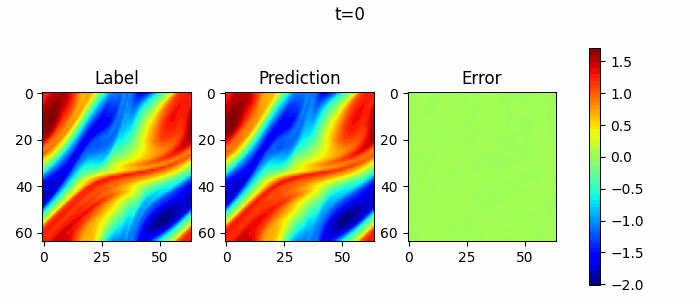

In [11]:
with open('images/result.gif', 'rb') as f:
    display(Image(data=f.read(), format='png', embed=True))